# MDD: сравнение latency ETA API

Metrics Driven Development: обоснование rollout улучшений по p95/p99, с guardrail по MAE/on-time rate.

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

np.random.seed(42)
existing_system_responses = np.random.normal(loc=3.5, scale=0.4, size=500_000)
improved_system_responses = np.random.normal(loc=2.0, scale=0.4, size=500_000)

In [5]:
def percentiles(x, ps=(50, 95, 99)):
    return {f'p{p}': np.percentile(x, p) for p in ps}

old_p = percentiles(existing_system_responses)
new_p = percentiles(improved_system_responses)
slo_sec = 2.5

print('Существующая:', old_p)
print('Улучшенная:  ', new_p)
print(f'Доля > {slo_sec}s (старая):', (existing_system_responses > slo_sec).mean() * 100, '%')
print(f'Доля > {slo_sec}s (новая): ', (improved_system_responses > slo_sec).mean() * 100, '%')

Существующая: {'p50': np.float64(3.49955791511592), 'p95': np.float64(4.157448752355925), 'p99': np.float64(4.429531176174134)}
Улучшенная:   {'p50': np.float64(1.999631357556774), 'p95': np.float64(2.656529453062368), 'p99': np.float64(2.9296963340573865)}
Доля > 2.5s (старая): 99.36019999999999 %
Доля > 2.5s (новая):  10.540199999999999 %


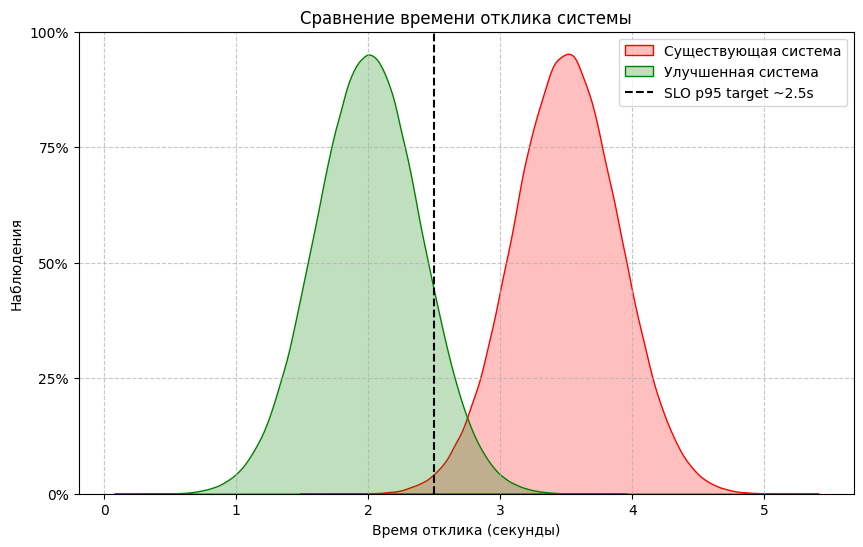

In [6]:
plt.figure(figsize=(10, 6))
sns.kdeplot(existing_system_responses, label='Существующая система', fill=True, color='red')
sns.kdeplot(improved_system_responses, label='Улучшенная система', fill=True, color='green')
plt.axvline(slo_sec, color='black', linestyle='--', label=f'SLO p95 target ~{slo_sec}s')
plt.title('Сравнение времени отклика системы')
plt.xlabel('Время отклика (секунды)')
plt.ylabel('Наблюдения')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
ax = plt.gca()
ymin, ymax = ax.get_ylim()
new_yticks = np.linspace(ymin, ymax, 5)
new_yticklabels = [f'{int((tick / ymax) * 100)}%' if ymax != 0 else '0%' for tick in new_yticks]
ax.set_yticks(new_yticks)
ax.set_yticklabels(new_yticklabels)
plt.show()

## Вывод MDD

1. **Целевая метрика:** p95 latency <= 2.5 с (не среднее).
2. **Наблюдение:** улучшение сдвигает распределение примерно на 1.5 с; доля запросов выше SLO падает заметно.
3. **Rollout:** катим canary 5% -> 100%, если p95 < 2.5 с и MAE/on-time не деградировали (guardrail).
4. **Следующие шаги:** кэш фичей, warm workers, ONNX; измерять p95 до/после каждой инициативы.

См. также [docs/MDD_LATENCY.md](../docs/MDD_LATENCY.md).